In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns
from scipy.stats import norm

In [14]:
### Import Data
df = pd.read_csv('ED_Cleaned_Data.csv')

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 911055 entries, 0 to 911054
Data columns (total 34 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   client_id                911055 non-null  int64  
 1   visit_id                 911055 non-null  int64  
 2   postal_code              899101 non-null  object 
 3   ED                       911055 non-null  object 
 4   gender                   911055 non-null  object 
 5   age                      911055 non-null  float64
 6   arrival_time             911055 non-null  object 
 7   triage_time              910898 non-null  object 
 8   CTAS                     911055 non-null  int64  
 9   tot_lab_orders           469110 non-null  float64
 10  tot_lab_test_ordered     469110 non-null  float64
 11  avg_lab_order_time_min   439750 non-null  float64
 12  tot_diag_orders          309396 non-null  float64
 13  tot_diag_test_ordered    309396 non-null  float64
 14  avg_

In [16]:
### Fix data type:

datetime_cols = [
    'arrival_time',
    'triage_time',
    'init_assess_time',
    'last_contact_time'
]

category_cols = [
    'client_id',
    'visit_id',
    'postal_code',
    'ED',
    'gender',
    'CTAS',
    'disposition',
    'arrival_mode',
    'ED_complaint',
    'chief_complaint',
    'period_of_day',
    'day_of_week',
    'season',
    'holiday',
    'admitted'
]

float_cols = [
    'age',
    'tot_lab_orders',
    'tot_lab_test_ordered',
    'avg_lab_order_time_min',
    'tot_diag_orders',
    'tot_diag_test_ordered',
    'avg_diag_order_time_min',
    'LOS_Hr',
    'wait_time_Hr',
    'service_time_min',
    'previous_visits'
]

df['service_time'] = pd.to_timedelta(
    df['service_time'],
    errors='coerce'
)

In [17]:
for col in datetime_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

for col in category_cols:
    df[col] = df[col].astype('category')

for col in float_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

#### Service Time

In [19]:
df_ST = df.copy()

In [20]:
df_ST['service_time_min'].describe()

count    910948.000000
mean        227.049556
std         727.563425
min      -19900.999998
25%          24.000000
50%          86.000000
75%         238.000000
max      496911.000000
Name: service_time_min, dtype: float64

In [21]:
### Omit extreme records from the data:

### Define upper threshold (remove top 1% of service time)
upper_threshold = df_ST['service_time_min'].quantile(0.99)

### Make a clean copy of the data: with non-negative service times and without extreme service times
df_ST = df_ST[
    (df_ST['service_time_min'] > 0) &
    (df_ST['service_time_min'] < upper_threshold)]

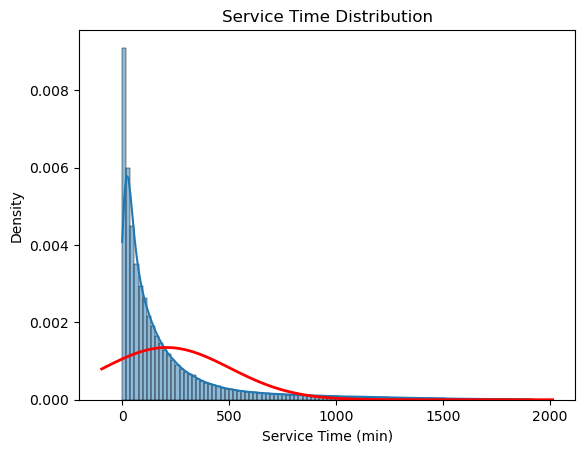

In [24]:
### Plot Service Time

# Choose the variable (service time)
data = df_ST['service_time_min'].dropna()

# Plot histogram + KDE
sns.histplot(data, bins=100, stat='density', kde=True)

# Fit normal distribution
mu, std = norm.fit(data)

# Create x values
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)

# Normal PDF
p = norm.pdf(x, mu, std)

# Overlay normal curve
plt.plot(x, p, 'r', linewidth=2)

#plt.title(f"Fit results: mu = {mu:.2f}, std = {std:.2f}")
plt.title("Service Time Distribution")
plt.xlabel("Service Time (min)")
plt.ylabel("Density")
#plt.savefig("Service_Time_Distribution.png", dpi=300, bbox_inches="tight")
plt.show();

#### Client ID & Visit ID

In [4]:
df['client_id'].nunique()

265479

In [5]:
df['visit_id'].nunique()

655676

#### Gender

In [26]:
df.groupby('gender', observed=True)['client_id'].nunique().reset_index(name='unique_clients')

,gender,unique_clients
0,Female,184110
1,Male,181054
2,Other,59
3,Undifferentiate,11


#### Age

In [35]:
df_age = df.copy()

In [36]:
df_age['age'].describe()

count    911055.000000
mean         43.961286
std          26.129155
min           5.000000
25%          21.000000
50%          41.000000
75%          64.000000
max         123.000000
Name: age, dtype: float64

In [57]:
summary_age_ED = (
    df_age
    .groupby('ED', observed=True)['age']
    .agg(
        count='count',
        min='min',
        Q1=lambda x: x.quantile(0.25),
        median='median',
        Q3=lambda x: x.quantile(0.75),
        max='max',
        mean='mean',
        sd='std'
    )
    .reset_index()
)

summary_age_ED

,ED,count,min,Q1,median,Q3,max,mean,sd
0,GH,140543,5.0,39.0,60.0,81.0,123.0,60.422163,24.122780
1,HSC-A,302231,6.0,36.0,48.0,63.0,123.0,50.946915,18.022363
2,HSC-P,256446,5.0,9.0,12.0,18.0,123.0,14.003923,5.710731
3,SBGH,211835,5.0,41.0,60.0,76.0,119.0,59.339816,21.794338


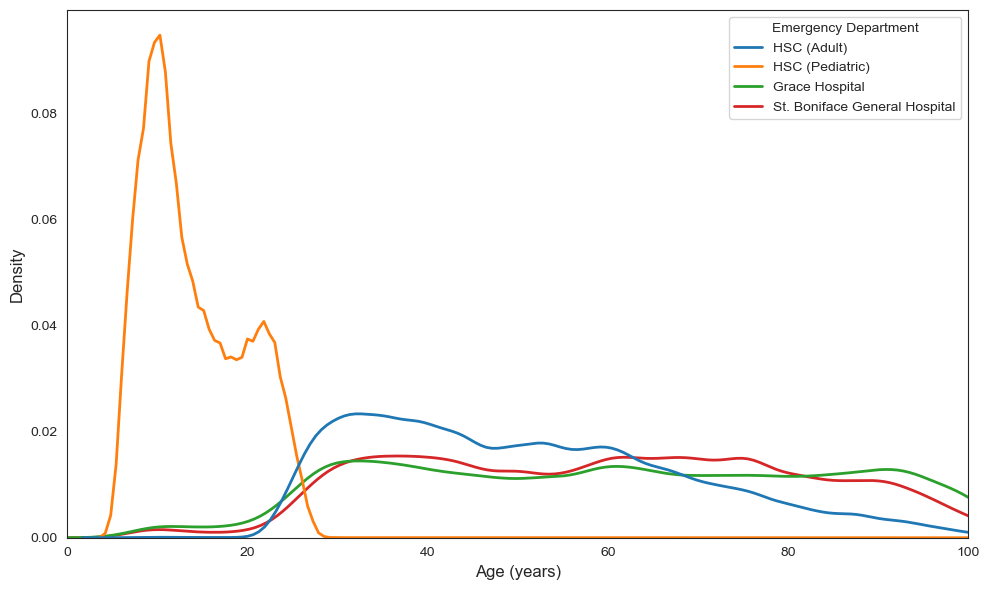

In [37]:
sns.set_style("white")

# Define order and labels
ed_order = ['HSC-A', 'HSC-P', 'GH', 'SBGH']
ed_labels = {
    'HSC-A': 'HSC (Adult)',
    'HSC-P': 'HSC (Pediatric)',
    'GH': 'Grace Hospital',
    'SBGH': 'St. Boniface General Hospital'
}

# Create label column
df_age['ED_label'] = df_age['ED'].map(ed_labels)

plt.figure(figsize=(10,6))

ax = sns.kdeplot(
    data=df_age,
    x='age',
    hue='ED_label',
    hue_order=[ed_labels[e] for e in ed_order],
    common_norm=False,
    linewidth=2
)

# Axis labels
ax.set_xlabel('Age (years)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
#ax.set_title('Age Distribution by Emergency Department', fontsize=14)

# FIX: Modify seaborn legend instead of creating a new one
legend = ax.get_legend()
legend.set_title('Emergency Department')
for text in legend.get_texts():
    text.set_fontsize(10)

plt.xlim(0, 100)
plt.tight_layout()
#plt.savefig("Age_vs_ED.png", dpi=300, bbox_inches="tight")
plt.show();

Age distribution is significantly different for different ED.

#### CTAS

In [8]:
df['CTAS'].value_counts()

CTAS
3    254935
4    173076
2    121766
5     92620
1     13279
Name: count, dtype: int64

#### Patient Flow & Timing Structure

In [38]:
df_timing = df.copy()

**Note**: Age distribution for HSC (Pediatric) is significantly different from other ED. Thus, we can remove children's hospital data.
To keep the children's hospital data comment next chunk.

In [40]:
# Remove rows for HSC-P
df_timing = df_timing[df_timing['ED'] != 'HSC-P']

# Also remove 'HSC-P' from the category list (optional but clean)
df_timing['ED'] = df_timing['ED'].cat.remove_categories('HSC-P')

In [41]:
df_timing['ED'].value_counts()

ED
HSC-A    302231
SBGH     211835
GH       140543
Name: count, dtype: int64

In [42]:
df_timing["wait_time"] = (
    (df_timing["init_assess_time"] - df_timing["triage_time"])
    .dt.total_seconds() / 60
)

df_timing["los"] = (
    (df_timing["last_contact_time"] - df_timing["arrival_time"])
    .dt.total_seconds() / 60
)

df_timing["service_time_new"] = (
    (df_timing["last_contact_time"] - df_timing["init_assess_time"])
    .dt.total_seconds() / 60
)

In [30]:
def clean_time_variable(series, upper_q=0.99):
    s = series.copy()

    # remove negatives
    s = s.where(s >= 0)

    # remove top 1%
    upper_threshold = s.quantile(upper_q)
    s = s.where(s <= upper_threshold)

    return s, upper_threshold

In [43]:
df_timing["wait_time_final"], wait_thr = clean_time_variable(df_timing["wait_time"])
df_timing["los_final"], los_thr = clean_time_variable(df_timing["los"])
df_timing["service_time_final"], svc_thr = clean_time_variable(df_timing["service_time_new"])

In [44]:
def summarize(series):
    s = series.dropna()
    return pd.Series({
        "N": s.shape[0],
        "Mean": s.mean(),
        "Std": s.std(),
        "Median": s.median(),
        "P75": s.quantile(0.75),
        "P90": s.quantile(0.90),
        "P95": s.quantile(0.95),
        "Min": s.min(),
        "Max": s.max()
    })

In [45]:
summary = pd.DataFrame({
    "Wait Time": summarize(df_timing["wait_time_final"]),
    "Service Time": summarize(df_timing["service_time_final"]),
    "LOS": summarize(df_timing["los_final"])
}).round(2)

summary

,Wait Time,Service Time,LOS
N,646302.00,58346.00,60802.00
Mean,150.88,265.14,411.63
Std,118.57,355.06,368.77
Median,123.00,133.00,304.00
P75,223.00,322.00,495.00
P90,324.00,719.00,874.00
P95,386.00,1066.00,1228.00
Min,0.00,0.00,0.00
Max,555.00,2395.00,2588.00


**CTAS vs wait time, service time, and LOS**

In [46]:
def p90(x):
    return x.quantile(0.90)

ctas_summary = df_timing.groupby("CTAS", observed=True).agg({
    "wait_time_final": ["mean", "std", "median", p90],
    "service_time_final": ["mean", "std", "median", p90],
    "los_final": ["mean", "std", "median", p90]
}).round(2)

ctas_summary.columns = [
    "Wait_Mean", "Wait_SD", "Wait_Median", "Wait_P90",
    "Service_Mean", "Service_SD", "Service_Median", "Service_P90",
    "LOS_Mean", "LOS_SD", "LOS_Median", "LOS_P90"
]

ctas_summary.reset_index(inplace=True)
ctas_summary

,CTAS,Wait_Mean,Wait_SD,Wait_Median,Wait_P90,Service_Mean,Service_SD,Service_Median,Service_P90,LOS_Mean,LOS_SD,LOS_Median,LOS_P90
0,1,27.22,40.87,17.0,54.0,349.62,374.81,206.5,888.4,382.76,388.03,235.5,908.9
1,2,123.20,114.72,84.0,294.0,377.96,390.48,246.5,929.7,502.09,399.72,380.0,1060.8
2,3,160.96,120.02,134.0,336.0,301.23,375.85,163.0,817.3,458.71,390.80,341.0,998.9
3,4,167.76,118.35,146.0,338.0,201.71,315.15,91.0,505.0,362.36,334.35,273.0,708.0
4,5,144.74,110.24,121.0,302.0,117.31,210.74,52.0,270.0,259.10,238.91,204.0,479.0


#### Admission (Disposition)

In [47]:
df_admin = df.copy()

In [48]:
df_admin['admitted'].value_counts(normalize=True)

admitted
0    0.846926
1    0.153074
Name: proportion, dtype: float64

CTAS vs Admission

In [49]:
admission_ctas = pd.crosstab(
    df_admin["CTAS"],
    df_admin["admitted"],
    normalize="index"
) * 100

admission_ctas = admission_ctas.round(1)
admission_ctas

admitted,0,1
CTAS,,
1,30.5,69.5
2,69.4,30.6
3,82.5,17.5
4,93.3,6.7
5,94.6,5.4


In [58]:
df_admin['admitted_num'] = df_admin['admitted'].astype(int)

In [59]:
pivot_admission = (
    df_admin
    .pivot_table(
        values='admitted_num',
        index='ED',
        columns='CTAS',
        aggfunc='mean',
        observed=False
    ) * 100
)

pivot_admission

CTAS,1,2,3,4,5
ED,,,,,
GH,59.645233,25.048380,17.106171,10.180283,6.117129
HSC-A,72.248614,37.919186,21.803439,11.280906,6.639679
HSC-P,77.994429,28.335415,10.313428,1.800188,0.992322
SBGH,65.785078,27.880985,18.995402,9.157350,4.320401


In [ ]:
### Admission Rate vs ED vs CTAS

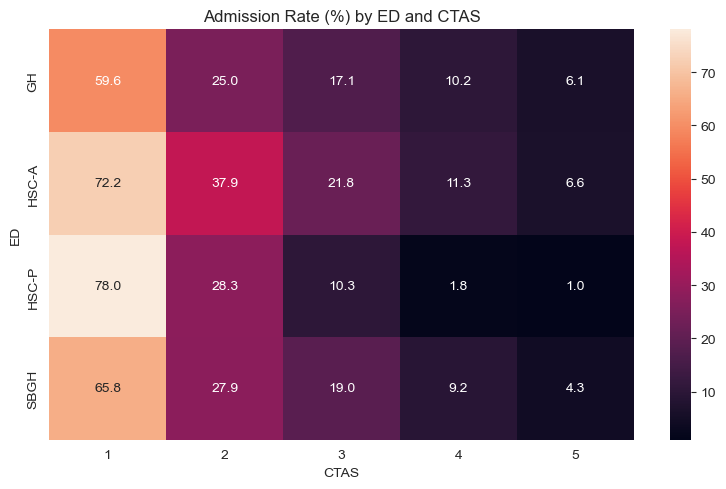

In [60]:
plt.figure(figsize=(8,5))

sns.heatmap(
    pivot_admission,
    annot=True,
    fmt=".1f"
)

plt.title('Admission Rate (%) by ED and CTAS')
plt.xlabel('CTAS')
plt.ylabel('ED')
plt.tight_layout()
#plt.savefig("Disposition_vs_ED_vs_CTAS.png", dpi=300, bbox_inches="tight")
plt.show();

#### Service Time for Different ED

In [50]:
df_ST['ED'].value_counts()

ED
HSC-A    281147
HSC-P    239977
SBGH     198078
GH       128435
Name: count, dtype: int64

In [29]:
### Grouped Summary Table

In [52]:
summary_ED_CTAS = (
    df_ST
    .groupby(['ED', 'CTAS'], observed=True)['service_time_min']
    .agg(['count', 'mean', 'median', 'std'])
    .reset_index()
    .sort_values(['ED', 'CTAS'])
)

summary_ED_CTAS

,ED,CTAS,count,mean,median,std
0,GH,1,1305,496.529502,351.0,429.001090
1,GH,2,22583,414.586725,268.0,403.040738
2,GH,3,48014,329.338276,163.0,398.972682
3,GH,4,36658,238.557013,94.0,353.212182
4,GH,5,19875,145.176201,51.0,263.572649
5,HSC-A,1,7382,324.474397,197.0,347.430507
6,HSC-A,2,42831,388.817772,278.0,361.694765
7,HSC-A,3,108467,287.069920,175.0,328.736131
8,HSC-A,4,76690,173.004212,88.0,249.821345
9,HSC-A,5,45777,108.881491,52.0,175.778998


In [31]:
### Pivot Table (for heatmap or interpretation)

In [54]:
pivot_mean = df_ST.pivot_table(
    values='service_time_min',
    index='ED',
    columns='CTAS',
    aggfunc='mean',
    observed=True
)

pivot_median = df_ST.pivot_table(
    values='service_time_min',
    index='ED',
    columns='CTAS',
    aggfunc='median',
    observed=True
)

In [33]:
### Visualization

In [35]:
### Heatmap

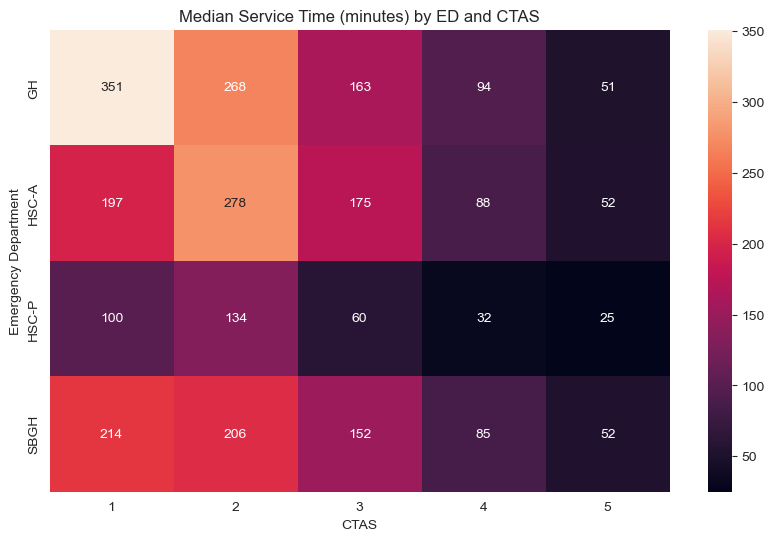

In [55]:
plt.figure(figsize=(10,6))

sns.heatmap(
    pivot_median,
    annot=True,
    fmt=".0f"
)

plt.title('Median Service Time (minutes) by ED and CTAS')
plt.xlabel('CTAS')
plt.ylabel('Emergency Department')
#plt.savefig("Service_Time_vs_ED_vs_CTAS.png", dpi=300, bbox_inches="tight")
plt.show()

#### Service Time and Disposition vs Lab and Diagnostic

In [94]:
df_ST_Lab_Diag = df.copy()

In [95]:
### Omit extreme records from the data:

### Define upper threshold (remove top 1% of service time)
upper_threshold = df_ST_Lab_Diag['service_time_min'].quantile(0.99)

### Make a clean copy of the data: with non-negative service times and without extreme service times
df_ST_Lab_Diag = df_ST_Lab_Diag[
    (df_ST_Lab_Diag['service_time_min'] > 0) &
    (df_ST_Lab_Diag['service_time_min'] < upper_threshold)]

In [96]:
### Note: Age distribution for HSC (Pediatric) is significantly different from other EDs. Thus, we can remove the children's hospital data.
### To keep the children's hospital data comment this chunk.

# Remove rows for HSC-P
df_ST_Lab_Diag = df_ST_Lab_Diag[df_ST_Lab_Diag['ED'] != 'HSC-P']

# Also remove 'HSC-P' from the category list (optional but clean)
df_ST_Lab_Diag['ED'] = df_ST_Lab_Diag['ED'].cat.remove_categories('HSC-P')

In [97]:
cols = [
    'tot_lab_orders',
    'tot_lab_test_ordered',
    'avg_lab_order_time_min',
    'tot_diag_orders',
    'tot_diag_test_ordered',
    'avg_diag_order_time_min'
]

In [98]:
### How common are missing values?
df_ST_Lab_Diag[cols].isna().sum()

tot_lab_orders             198380
tot_lab_test_ordered       198380
avg_lab_order_time_min     217384
tot_diag_orders            343797
tot_diag_test_ordered      343797
avg_diag_order_time_min    352225
dtype: int64

In [99]:
### How common are zeros?
(df_ST_Lab_Diag[cols] == 0).sum()

tot_lab_orders               3307
tot_lab_test_ordered         3307
avg_lab_order_time_min     162828
tot_diag_orders              5838
tot_diag_test_ordered        5838
avg_diag_order_time_min     17943
dtype: int64

In [100]:
### Are missing values linked to zeros?
df_ST_Lab_Diag[['tot_lab_orders', 'tot_lab_test_ordered', 'avg_lab_order_time_min']].head(20)

,tot_lab_orders,tot_lab_test_ordered,avg_lab_order_time_min
0,5.0,48.0,25.0
1,7.0,49.0,0.0
2,6.0,41.0,241.0
4,9.0,109.0,54.0
5,34.0,383.0,1539.0
6,7.0,106.0,421.0
7,14.0,195.0,210.0
8,7.0,64.0,1051.0
10,3.0,43.0,0.0
12,11.0,167.0,542.0


In [101]:
df_ST_Lab_Diag[['tot_diag_orders', 'tot_diag_test_ordered', 'avg_diag_order_time_min']].head(20)

,tot_diag_orders,tot_diag_test_ordered,avg_diag_order_time_min
0,2.0,2.0,80.0
1,NaN,NaN,NaN
2,2.0,2.0,336.0
4,2.0,2.0,327.0
5,2.0,2.0,34.0
6,1.0,1.0,815.0
7,0.0,0.0,82.0
8,0.0,0.0,719.0
10,NaN,NaN,NaN
12,0.0,0.0,162.0


In [102]:
### when there are missing values:

pd.crosstab(
    df_ST_Lab_Diag['tot_lab_orders'].isna(),
    df_ST_Lab_Diag['avg_lab_order_time_min'].isna()
)

avg_lab_order_time_min,False,True
tot_lab_orders,,
False,390276,19004
True,0,198380


Note: whenever tot_lab_orders is missing (isna == True), avg_lab_order_time_min is also missing, suggesting that the average lab order time cannot be computed when no lab-related information is available. In contrast, most observations with recorded lab orders also have recorded average lab order times. However, there are cases where lab orders are present but the average lab order time is missing, indicating possible incomplete timing information or differences in how the timing variable was recorded.

In [103]:
### For diagnostic

pd.crosstab(
    df_ST_Lab_Diag['tot_diag_orders'].isna(),
    df_ST_Lab_Diag['avg_diag_order_time_min'].isna()
)

avg_diag_order_time_min,False,True
tot_diag_orders,,
False,255435,8428
True,0,343797


In [104]:
### When the value is zero:

pd.crosstab(
    df_ST_Lab_Diag['tot_lab_orders'] == 0,
    df_ST_Lab_Diag['avg_lab_order_time_min'].isna()
)

avg_lab_order_time_min,False,True
tot_lab_orders,,
False,388611,215742
True,1665,1642


This result suggests that zero lab orders and missing average lab order times are strongly related, but not perfectly equivalent. Most patients with tot_lab_orders = 0 also have missing avg_lab_order_time_min, indicating that when no lab orders are placed, the average lab timing is often undefined or not recorded. However, there are also many patients with nonzero lab orders and non-missing timing information, which is expected. Interestingly, a small number of observations show zero lab orders with recorded average lab order times, and vice versa, suggesting possible inconsistencies, delayed entries, or differences in how these variables were constructed in the operational system. Overall, the results indicate that missingness in the timing variable is largely structural and related to the absence of lab activity rather than purely random missing data.

In [105]:
### For diagnostics

pd.crosstab(
    df_ST_Lab_Diag['tot_diag_orders'] == 0,
    df_ST_Lab_Diag['avg_diag_order_time_min'].isna()
)

avg_diag_order_time_min,False,True
tot_diag_orders,,
False,252901,348921
True,2534,3304


In [106]:
### Correlation (lab)

df_ST_Lab_Diag[
    ['tot_lab_orders', 'tot_lab_test_ordered']
].corr()

,tot_lab_orders,tot_lab_test_ordered
tot_lab_orders,1.000000,0.844075
tot_lab_test_ordered,0.844075,1.000000


In [107]:
df_ST_Lab_Diag[
    ['tot_lab_orders', 'avg_lab_order_time_min']
].corr()

,tot_lab_orders,avg_lab_order_time_min
tot_lab_orders,1.000000,0.452283
avg_lab_order_time_min,0.452283,1.000000


In [108]:
df_ST_Lab_Diag[
    ['tot_lab_test_ordered', 'avg_lab_order_time_min']
].corr()

,tot_lab_test_ordered,avg_lab_order_time_min
tot_lab_test_ordered,1.000000,0.434595
avg_lab_order_time_min,0.434595,1.000000


**Note**: "tot_lab_orders" and "tot_lab_test_ordered" are highly correlated. However, "tot_lab_orders" and "tot_lab_order_time_min" & "tot_lab_test_ordered" and "avg_lab_order_time_min" do not show significant correlation.

In [109]:
### Correlation (diagnostic)

df_ST_Lab_Diag[
    ['tot_diag_orders', 'tot_diag_test_ordered']
].corr()

,tot_diag_orders,tot_diag_test_ordered
tot_diag_orders,1.000000,0.977566
tot_diag_test_ordered,0.977566,1.000000


In [110]:
df_ST_Lab_Diag[
    ['tot_diag_orders', 'avg_diag_order_time_min']
].corr()

,tot_diag_orders,avg_diag_order_time_min
tot_diag_orders,1.000000,0.030159
avg_diag_order_time_min,0.030159,1.000000


In [111]:
df_ST_Lab_Diag[
    ['tot_diag_test_ordered', 'avg_diag_order_time_min']
].corr()

,tot_diag_test_ordered,avg_diag_order_time_min
tot_diag_test_ordered,1.000000,0.033582
avg_diag_order_time_min,0.033582,1.000000


**Note**: "tot_diag_orders" and "tot_diag_test_ordered" are highly correlated. However, "tot_diag_orders" and "tot_diag_order_time_min" & "tot_diag_test_ordered" and "avg_diag_order_time_min" do not show significant correlation.

**Now check how service time and disposition chnages with lab and diagnostic orders:**

In [112]:
df_ST_Lab_Diag['has_lab'] = (df_ST_Lab_Diag['tot_lab_orders'] > 0).astype(int)
df_ST_Lab_Diag['has_diag'] = (df_ST_Lab_Diag['tot_diag_orders'] > 0).astype(int)

**Service Time**

In [113]:
df_ST_Lab_Diag.groupby('has_lab')['service_time_min'].describe()

,count,mean,std,min,25%,50%,75%,max
has_lab,,,,,,,,
0,201687.0,80.363102,122.497107,2.000000e-08,16.0,45.0,98.0,1917.0
1,405973.0,342.538644,359.940719,2.000000e-08,99.0,214.0,444.0,1917.0


No lab order, the service time is shorter.

At least one lab order, higher service time.

In [114]:
df_ST_Lab_Diag.groupby('has_diag')['service_time_min'].describe()

,count,mean,std,min,25%,50%,75%,max
has_diag,,,,,,,,
0,349635.0,151.322316,231.578998,2.000000e-08,24.0,70.0,176.0,1917.0
1,258025.0,396.713714,379.672742,2.000000e-08,129.0,259.0,528.0,1917.0


No diagnostic, service time is significantly lower.

With the diagnostic, the service time is significantly high.

In [ ]:
### Service time with lab & diagnostic

In [115]:
df_ST_Lab_Diag.groupby(
    ['has_lab', 'has_diag']
)['service_time_min'].describe()

count        mean         std           min    25%  \
has_lab has_diag                                                          
0       0         152783.0   64.719393  108.710642  2.000000e-08   12.0   
        1          48904.0  129.236259  147.685803  2.000000e-08   53.0   
1       0         196852.0  218.537556  275.210416  2.000000e-08   51.0   
        1         209121.0  459.264665  390.022868  2.000000e-08  176.0   

                    50%    75%     max  
has_lab has_diag                        
0       0          33.0   75.0  1917.0  
        1          92.0  154.0  1911.0  
1       0         128.0  261.0  1917.0  
        1         322.0  625.0  1917.0

**Service Time * CTAS * Lab**

In [139]:
df_ST_Lab_Diag.groupby(
    ['CTAS', 'has_lab']
, observed=False)['service_time_min'].describe()

count        mean         std           min    25%    50%  \
CTAS has_lab                                                                 
1    0           399.0  165.230576  243.032634  1.000000e+00   24.0   73.0   
     1         11805.0  355.397205  364.804393  2.001667e-08  105.0  219.0   
2    0         11844.0  127.121074  178.767938  2.000000e-08   25.0   72.0   
     1        104322.0  391.633404  365.383950  2.000000e-08  136.0  269.0   
3    0         59004.0   94.348620  140.382810  2.000000e-08   19.0   54.0   
     1        178715.0  355.698475  367.164640  2.000000e-08  105.0  225.0   
4    0         73237.0   75.366959  111.827996  2.000000e-08   17.0   44.0   
     1         84274.0  286.909438  340.708147  2.000000e-08   71.0  164.0   
5    0         57203.0   62.060521   92.030361  2.000000e-08   14.0   35.0   
     1         26857.0  233.173400  296.247662  2.000000e-08   55.0  135.0   

                75%     max  
CTAS has_lab                 
1    0        203.0  1818.0  
     1        468.0  1912.0  
2    0        156.0  1867.0  
     1        521.0  1917.0  
3    0        115.0  1917.0  
     1        464.0  1917.0  
4    0         93.0  1887.0  
     1        347.0  1917.0  
5    0         77.0  1877.0  
     1        273.0  1917.0

**Service Time * CTAS * Diagnostic**

In [141]:
df_ST_Lab_Diag.groupby(
    ['CTAS', 'has_diag']
, observed=False)['service_time_min'].describe()

count        mean         std           min    25%    50%  \
CTAS has_diag                                                                 
1    0           3084.0  248.286965  288.301130  1.000000e+00   65.0  146.0   
     1           9120.0  383.297588  379.035493  2.001667e-08  117.0  241.0   
2    0          48543.0  241.630348  291.664647  2.000000e-08   56.0  145.0   
     1          67623.0  452.984044  377.927831  2.000000e-08  179.0  327.0   
3    0         130936.0  176.386838  249.745422  2.000000e-08   31.0   91.0   
     1         106783.0  431.156757  390.709136  2.000000e-08  150.0  291.0   
4    0         103706.0  118.191918  197.075071  2.000000e-08   20.0   53.0   
     1          53805.0  324.160301  358.663924  2.000000e-08   94.0  187.0   
5    0          63366.0   79.850409  139.076682  2.000000e-08   14.0   37.0   
     1          20694.0  229.660046  295.001600  2.000000e-08   64.0  125.0   

                  75%     max  
CTAS has_diag                  
1    0         312.25  1881.0  
     1         514.25  1912.0  
2    0         299.00  1917.0  
     1         614.00  1917.0  
3    0         210.00  1917.0  
     1         588.00  1917.0  
4    0         132.00  1914.0  
     1         394.00  1917.0  
5    0          90.00  1917.0  
     1         258.00  1914.0

Note: Having lab orders changes the service time significantly in all CTAS levels. However, for diagnostic orders, this changes a little bit. For CTAS 1, service time with/without diagnostic orders is somewhat close. 

**Correlation Between Service Time vs Lab and Diagnostic Orders:**

**Lab**

In [122]:
df_ST_Lab_Diag[
    ['tot_lab_orders', 'service_time_min']
].corr()

,tot_lab_orders,service_time_min
tot_lab_orders,1.000000,0.431916
service_time_min,0.431916,1.000000


In [123]:
df_ST_Lab_Diag[
    ['tot_lab_test_ordered', 'service_time_min']
].corr()

,tot_lab_test_ordered,service_time_min
tot_lab_test_ordered,1.000000,0.393526
service_time_min,0.393526,1.000000


In [134]:
df_ST_Lab_Diag[
    ['avg_lab_order_time_min', 'service_time_min']
].corr()

,avg_lab_order_time_min,service_time_min
avg_lab_order_time_min,1.000000,0.436087
service_time_min,0.436087,1.000000


**Diagnostic**

In [132]:
df_ST_Lab_Diag[
    ['tot_diag_orders', 'service_time_min']
].corr()

,tot_diag_orders,service_time_min
tot_diag_orders,1.000000,0.236286
service_time_min,0.236286,1.000000


In [131]:
df_ST_Lab_Diag[
    ['tot_diag_test_ordered', 'service_time_min']
].corr()

,tot_diag_test_ordered,service_time_min
tot_diag_test_ordered,1.000000,0.237756
service_time_min,0.237756,1.000000


In [133]:
df_ST_Lab_Diag[
    ['avg_diag_order_time_min', 'service_time_min']
].corr()

,avg_diag_order_time_min,service_time_min
avg_diag_order_time_min,1.000000,0.069614
service_time_min,0.069614,1.000000


Based on the correlation with service time, we can see some dependency between:

'tot_lab_orders','tot_lab_test_ordered', 'avg_lab_order_time_min' vs 'service_time_min'

and 

'tot_diag_orders','tot_diag_test_ordered' vs 'service_time_min'

**Disposition**

In [135]:
pd.crosstab(df_ST_Lab_Diag['has_lab'], df_ST_Lab_Diag['admitted'], normalize='index')

admitted,0,1
has_lab,,
0,0.942902,0.057098
1,0.752387,0.247613


If a patient has no lab order, less likely to be admitted.

If a patient has a lab order, less likely to be admitted.

In [136]:
pd.crosstab(df_ST_Lab_Diag['has_diag'], df_ST_Lab_Diag['admitted'], normalize='index')

admitted,0,1
has_diag,,
0,0.890892,0.109108
1,0.713625,0.286375


If a patient has no diagnostic order, less likely to be admitted.

If a patient has a diagnostic order, less likely to be admitted.

Disposition indicated the severity of patients. Having a lab/diagnostic order does not significantly increase the chance of being admitted.

In [137]:
pd.crosstab(
    [df_ST_Lab_Diag['has_lab'],
     df_ST_Lab_Diag['has_diag']],
    df_ST_Lab_Diag['admitted'],
    normalize='index'
)

admitted                 0         1
has_lab has_diag                    
0       0         0.937650  0.062350
        1         0.959308  0.040692
1       0         0.854601  0.145399
        1         0.656170  0.343830

When lab and diagnostic orders are present, the chance of being admitted increases.